In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Reload modules to pick up changes
import importlib
import sys

# Remove cached modules
for module in list(sys.modules.keys()):
    if 'InterventionalPFN' in module or 'SimplePFN' in module:
        del sys.modules[module]

# Now import fresh
from InterventionalPFN_sklearn import InterventionalPFNSklearn
from SimplePFN_sklearn import SimplePFNSklearn
from sklearn.ensemble import RandomForestRegressor
from src.priordata_processing.BasicProcessing import BasicProcessing
import torch


In [3]:
config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/checkpoints/simple_pfn_16635966.0/step_20000.pt"

intpfn = InterventionalPFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    n_estimators = 1,
    verbose=True  # Enable verbose mode to see what's being loaded
)

# Now the config should load properly with the fixed load() method
intpfn.load(override_kwargs={
    "num_features": 50  # Adjust based on your data (50 total - 1 target)
})

config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/checkpoints/simple_pfn_16631563.0/step_32000.pt"

obspfn = SimplePFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    n_estimators = 1
)
obspfn.load(override_kwargs={
    "num_features": 50  # Adjust based on your data (50 total - 1 target)
})


# Processor should match the config: 50 features (excluding target, including intervention column)
processor = BasicProcessing(
    n_features=49,
    max_n_features=49,
    n_train_samples = 500,
    max_n_train_samples=500,
    n_test_samples=500,
    max_n_test_samples=500,
    dropout_prob=0.0,
    target_feature=2,
    intervened_feature=0,
    negative_one_one_scaling=True,
    standardize=True,
    yeo_johnson=False,
    remove_outliers=True,
    outlier_quantile=0.95,
    shuffle_samples=False,
    shuffle_features=False,
    eps = 1e-8
)



[InterventionalPFNSklearn] Loading with config_path: /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/FirstTests/configs/basic.yaml
[InterventionalPFNSklearn] verbose=True
[InterventionalPFNSklearn] Config loaded. Top-level keys: ['experiment_name', 'description', 'scm_config', 'dataset_config', 'preprocessing_config', 'model_config', 'training_config']
[InterventionalPFNSklearn] Loaded model_kwargs from config: {'num_features': 50, 'd_model': 256, 'depth': 6, 'heads_feat': 4, 'heads_samp': 4, 'dropout': 0.1, 'output_dim': 1, 'hidden_mult': 2, 'normalize_features': False}
[InterventionalPFNSklearn] BarDistribution enabled with 1000 bars
[InterventionalPFNSklearn] Model output_dim set to 1004
[InterventionalPFNSklearn] Building InterventionalPFN with kwargs: {'num_features': 50, 'd_model': 256, 'depth': 6, 'heads_feat': 4, 'heads_samp': 4, 'dropout': 0.1, 'output_dim': 1004, 'hidden_mult': 2, 'normalize_features': False}
[InterventionalPFNSklearn] Loading checkpoint from /

### Three variables, no hidden confounder

In [4]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/src

/Users/arikreuter/Documents/PhD/CausalPriorFitting/src


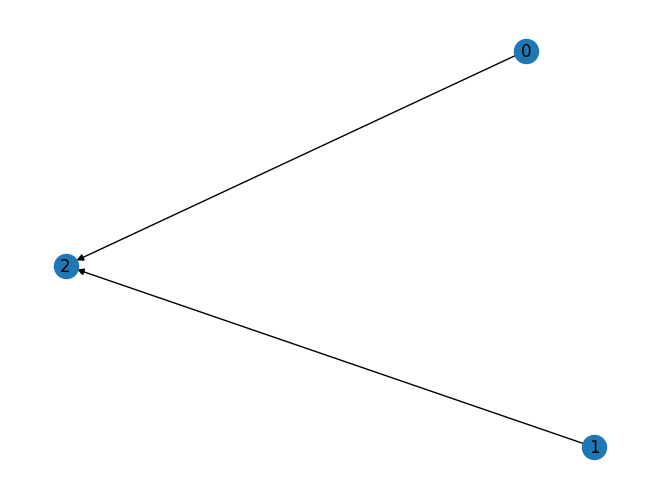

RF MSE: 0.22650011614213972


/var/folders/ng/4_7_0hz56vnfj1yd8btkt5h80007z9/T/ipykernel_77588/370761125.py:97: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  obspfn_mse = torch.mean((Y_test.reshape(-1,1) - obspfn_preds)**2)


Obs PFN MSE: 0.22161027789115906
[SimplePFNSklearn] Initial k-means with k=2
Int PFN MSE: 0.21359746158123016
Int PFN MSE: 0.21359746158123016


/var/folders/ng/4_7_0hz56vnfj1yd8btkt5h80007z9/T/ipykernel_77588/370761125.py:110: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intpfn_mse = torch.mean((Y_test.reshape(-1,1) - intpfn_preds)**2)


In [5]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism

NUM_NODES = 3
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             #(1, 0), 
             (0, 2)]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: x
)

# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

r = scm.propagate(num_samples=BATCH_SIZE)

N_train = r[0].shape[0]//2
N_test = r[0].shape[0] - N_train 

r_train = {k: v[:N_train].reshape(-1, 1) for k, v in r.items()}
r_test = {k: v[N_train:].reshape(-1, 1) for k, v in r.items()}


X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(r_train, r_test)

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1) 

# predict with random forest 

rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())
rf_preds = torch.tensor(rf.predict(XT_test.numpy()))
rf_mse = torch.mean((Y_test.reshape(-1,1) - rf_preds)**2)
print(f"RF MSE: {rf_mse}")

# predict with observational pfn
obspfn_preds = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy())
obspfn_mse = torch.mean((Y_test.reshape(-1,1) - obspfn_preds)**2)
print(f"Obs PFN MSE: {obspfn_mse}")

X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)

intpfn_preds = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy()
)
intpfn_mse = torch.mean((Y_test.reshape(-1,1) - intpfn_preds)**2)
print(f"Int PFN MSE: {intpfn_mse}")





# Simpe observational prediction

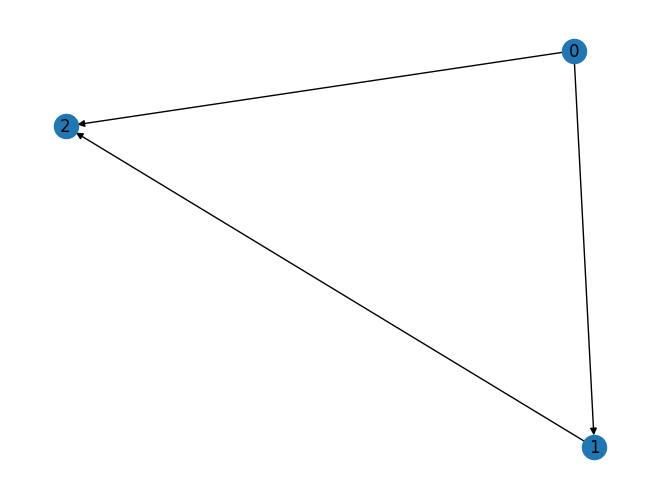

RF MSE: 0.14775334868624532


/var/folders/ng/4_7_0hz56vnfj1yd8btkt5h80007z9/T/ipykernel_77588/3921039979.py:105: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  obspfn_mse = torch.mean((Y_test.reshape(-1,1) - obspfn_preds)**2)


Obs PFN MSE: 0.14755600690841675
[SimplePFNSklearn] Initial k-means with k=2
Int PFN MSE: 0.1485683172941208
Int PFN MSE: 0.1485683172941208


/var/folders/ng/4_7_0hz56vnfj1yd8btkt5h80007z9/T/ipykernel_77588/3921039979.py:118: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intpfn_mse = torch.mean((Y_test.reshape(-1,1) - intpfn_preds)**2)


In [6]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism

NUM_NODES = 3
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (0, 1), 
             (0, 2)]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: x
)

mechanisms[1] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: x
)


# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

r = scm.propagate(num_samples=BATCH_SIZE)

N_train = r[0].shape[0]//2
N_test = r[0].shape[0] - N_train 

r_train = {k: v[:N_train].reshape(-1, 1) for k, v in r.items()}
r_test = {k: v[N_train:].reshape(-1, 1) for k, v in r.items()}


X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(r_train, r_test)

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1) 

# predict with random forest 

rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())
rf_preds = torch.tensor(rf.predict(XT_test.numpy()))
rf_mse = torch.mean((Y_test.reshape(-1,1) - rf_preds)**2)
print(f"RF MSE: {rf_mse}")

# predict with observational pfn
obspfn_preds = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy())
obspfn_mse = torch.mean((Y_test.reshape(-1,1) - obspfn_preds)**2)
print(f"Obs PFN MSE: {obspfn_mse}")

X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)

intpfn_preds = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy()
)
intpfn_mse = torch.mean((Y_test.reshape(-1,1) - intpfn_preds)**2)
print(f"Int PFN MSE: {intpfn_mse}")





In [ ]:
from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism

NUM_NODES = 3
p = 0.5 
SEED = 42
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
    num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (0, 1), 
             (0, 2)]
graph.clear_edges()
graph.add_edges_from(new_edges)

causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

causal_dag.draw()

# mechanisms 
mechanisms = {}

mechanisms[2] = LinearMechanism(
        input_dim = 2,

    weights = [1.0, 1.0],
    nonlinearity= lambda x: x
)

mechanisms[1] = LinearMechanism(
        input_dim = 1,

    weights = [1.0],
    nonlinearity= lambda x: x
)


# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = NormalDistribution(mean = 0, std = 1)

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var]  = NormalDistribution(mean = 0, std = 1)


scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms=False
)

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

r = scm.propagate(num_samples=BATCH_SIZE)

N_train = r[0].shape[0]//2
N_test = r[0].shape[0] - N_train 

r_train = {k: v[:N_train].reshape(-1, 1) for k, v in r.items()}
r_test = {k: v[N_train:].reshape(-1, 1) for k, v in r.items()}


X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(r_train, r_test)

XT_train = torch.cat([X_train, T_train], dim=1)
XT_test = torch.cat([X_test, T_test], dim=1) 

# predict with random forest 

rf = RandomForestRegressor(n_estimators=10)
rf.fit(XT_train.numpy(), Y_train.numpy().ravel())
rf_preds = torch.tensor(rf.predict(XT_test.numpy()))
rf_mse = torch.mean((Y_test.reshape(-1,1) - rf_preds)**2)
print(f"RF MSE: {rf_mse}")

# predict with observational pfn
obspfn_preds = obspfn.predict(
    X_train = XT_train.numpy(), 
    y_train = Y_train.squeeze().numpy(), 
    X_test = XT_test.numpy())
obspfn_mse = torch.mean((Y_test.reshape(-1,1) - obspfn_preds)**2)
print(f"Obs PFN MSE: {obspfn_mse}")

X_obs_ext = torch.cat([X_train, torch.zeros_like(T_train)], dim=1)
X_intv_ext = torch.cat([X_test, T_test], dim=1)

intpfn_preds = intpfn.predict(
    X_obs = X_obs_ext.numpy(),
    T_obs = T_train.numpy(),
    Y_obs = Y_train.squeeze().numpy(),
    X_intv= X_intv_ext.numpy(),
    T_intv= T_test.numpy()
)
intpfn_mse = torch.mean((Y_test.reshape(-1,1) - intpfn_preds)**2)
print(f"Int PFN MSE: {intpfn_mse}")



